# 01 - Decision Trees (CART)

Part of Classical ML — Tree-Based Methods. First topic: build CART from scratch (both classification and regression), verify it matches `sklearn` exactly, then verify every theoretical claim from the companion `.md` numerically — the concavity comparison, greedy suboptimality on XOR data, cost-complexity pruning, and scale invariance.

**Book references:** ESL §9.2 (Tree-Based Methods, the canonical treatment); Murphy Ch.18 (Trees, Forests, Bagging, and Boosting).

# Part A - Building CART From Scratch

Impurity functions, the greedy recursive splitting algorithm, and prediction -- implemented directly from the pseudocode in the companion `.md`, then verified against `sklearn.tree.DecisionTreeClassifier`/`DecisionTreeRegressor` on the same data.

In [2]:
import numpy as np

def gini(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1 - np.sum(p**2)

def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return -np.sum(p * np.log2(p + 1e-12))

def mse_impurity(y):
    return np.mean((y - y.mean())**2)

class Node:
    def __init__(self, value=None, feature=None, threshold=None, left=None, right=None):
        self.value, self.feature, self.threshold = value, feature, threshold
        self.left, self.right = left, right
    def is_leaf(self):
        return self.value is not None

In [3]:
def best_split(X, y, impurity_fn):
    n, d = X.shape
    parent_impurity = impurity_fn(y)
    best_gain, best_feat, best_thresh = -1, None, None
    for feat in range(d):
        order = np.argsort(X[:, feat])
        xs = X[order, feat]
        for i in range(1, n):
            if xs[i] == xs[i - 1]:
                continue                                    # only midpoints between DISTINCT values matter
            thresh = (xs[i] + xs[i - 1]) / 2
            left_mask = X[:, feat] <= thresh
            if left_mask.sum() == 0 or left_mask.sum() == n:
                continue
            yl, yr = y[left_mask], y[~left_mask]
            weighted_impurity = (len(yl)/n)*impurity_fn(yl) + (len(yr)/n)*impurity_fn(yr)
            gain = parent_impurity - weighted_impurity
            if gain > best_gain:
                best_gain, best_feat, best_thresh = gain, feat, thresh
    return best_gain, best_feat, best_thresh

def build_tree(X, y, impurity_fn, leaf_value_fn, max_depth, depth=0, min_samples_split=2):
    if depth >= max_depth or len(y) < min_samples_split or impurity_fn(y) == 0:
        return Node(value=leaf_value_fn(y))
    gain, feat, thresh = best_split(X, y, impurity_fn)
    if gain <= 0 or feat is None:
        return Node(value=leaf_value_fn(y))
    mask = X[:, feat] <= thresh
    left = build_tree(X[mask], y[mask], impurity_fn, leaf_value_fn, max_depth, depth+1, min_samples_split)
    right = build_tree(X[~mask], y[~mask], impurity_fn, leaf_value_fn, max_depth, depth+1, min_samples_split)
    return Node(feature=feat, threshold=thresh, left=left, right=right)

def predict_one(node, x):
    while not node.is_leaf():
        node = node.left if x[node.feature] <= node.threshold else node.right
    return node.value

def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

def majority_class(y):
    vals, counts = np.unique(y, return_counts=True)
    return vals[np.argmax(counts)]

In [4]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.datasets import make_classification, make_regression

# --- Classification, Gini ---
X, y = make_classification(n_samples=200, n_features=4, n_informative=3, n_redundant=0, random_state=0)
tree_scratch = build_tree(X, y, gini, majority_class, max_depth=4)
preds_scratch = predict(tree_scratch, X)
sk_tree = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=0).fit(X, y)
print("Gini classification -- prediction agreement with sklearn:", np.mean(preds_scratch == sk_tree.predict(X)))

# --- Classification, Entropy ---
tree_entropy = build_tree(X, y, entropy, majority_class, max_depth=4)
sk_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=0).fit(X, y)
print("Entropy classification -- agreement:", np.mean(predict(tree_entropy, X) == sk_entropy.predict(X)))

# --- Regression, MSE ---
Xr, yr = make_regression(n_samples=200, n_features=3, noise=5.0, random_state=0)
tree_reg = build_tree(Xr, yr, mse_impurity, lambda y: y.mean(), max_depth=4)
preds_reg = predict(tree_reg, Xr)
sk_reg = DecisionTreeRegressor(criterion="squared_error", max_depth=4, random_state=0).fit(Xr, yr)
print("Regression (MSE) -- max abs diff from sklearn:", np.max(np.abs(preds_reg - sk_reg.predict(Xr))))

Gini classification -- prediction agreement with sklearn: 1.0
Entropy classification -- agreement: 1.0
Regression (MSE) -- max abs diff from sklearn: 2.842170943040401e-14


# Part B - The Concavity Comparison: the Classic ESL Worked Example

A balanced 400/400 parent node. Split A produces children (300,100) and (100,300). Split B produces children (200,400) and (200,0) -- one perfectly pure child. Misclassification error should be exactly tied; Gini and Entropy should both strongly prefer Split B.

In [5]:
def misclass_error(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1 - p.max()

parent = np.array([0]*400 + [1]*400)
A_left, A_right = np.array([0]*300 + [1]*100), np.array([0]*100 + [1]*300)
B_left, B_right = np.array([0]*200 + [1]*400), np.array([0]*200)

print(f"{'Criterion':25s} | {'Split A gain':>13s} | {'Split B gain':>13s}")
for name, fn in [("Gini", gini), ("Entropy", entropy), ("Misclassification Error", misclass_error)]:
    parent_imp = fn(parent)
    gain_A = parent_imp - ((400/800)*fn(A_left) + (400/800)*fn(A_right))
    gain_B = parent_imp - ((600/800)*fn(B_left) + (200/800)*fn(B_right))
    print(f"{name:25s} | {gain_A:13.4f} | {gain_B:13.4f}")

print("\nMisclassification error is exactly tied (0.25 = 0.25) -- it cannot tell these splits apart.")
print("Gini and Entropy both correctly, strongly prefer Split B (the one with a PURE child).")

Criterion                 |  Split A gain |  Split B gain
Gini                      |        0.1250 |        0.1667
Entropy                   |        0.1887 |        0.3113
Misclassification Error   |        0.2500 |        0.2500

Misclassification error is exactly tied (0.25 = 0.25) -- it cannot tell these splits apart.
Gini and Entropy both correctly, strongly prefer Split B (the one with a PURE child).


# Part C - Greedy Suboptimality: the XOR Problem

Data where the label is the XOR of two binary features. A greedy, single-feature-at-a-time search should see ZERO impurity reduction from either feature alone -- yet the two features together perfectly separate the classes.

In [6]:
rng = np.random.default_rng(0)
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]]*25, dtype=float)
X_xor += rng.normal(scale=0.05, size=X_xor.shape)
y_xor = np.array([0,1,1,0]*25)

parent_gini = gini(y_xor)
print("parent Gini (perfectly mixed):", parent_gini)

for feat in [0, 1]:
    mask = X_xor[:, feat] <= 0.5
    yl, yr = y_xor[mask], y_xor[~mask]
    weighted = (len(yl)/len(y_xor))*gini(yl) + (len(yr)/len(y_xor))*gini(yr)
    print(f"split on feature {feat} alone -- gain: {parent_gini - weighted:.6f}")

print("\nNeither single-feature split reduces impurity AT ALL.")
print("Yet splitting on BOTH features (one after the other) perfectly separates every quadrant:")
for name, m in [("(0,0)", (X_xor[:,0]<=0.5)&(X_xor[:,1]<=0.5)),
                 ("(0,1)", (X_xor[:,0]<=0.5)&(X_xor[:,1]>0.5)),
                 ("(1,0)", (X_xor[:,0]>0.5)&(X_xor[:,1]<=0.5)),
                 ("(1,1)", (X_xor[:,0]>0.5)&(X_xor[:,1]>0.5))]:
    print(f"  quadrant {name}: classes present = {np.unique(y_xor[m])}")

parent Gini (perfectly mixed): 0.5
split on feature 0 alone -- gain: 0.000000
split on feature 1 alone -- gain: 0.000000

Neither single-feature split reduces impurity AT ALL.
Yet splitting on BOTH features (one after the other) perfectly separates every quadrant:
  quadrant (0,0): classes present = [0]
  quadrant (0,1): classes present = [1]
  quadrant (1,0): classes present = [1]
  quadrant (1,1): classes present = [0]


# Part D - Depth, Bias-Variance, and Cost-Complexity Pruning

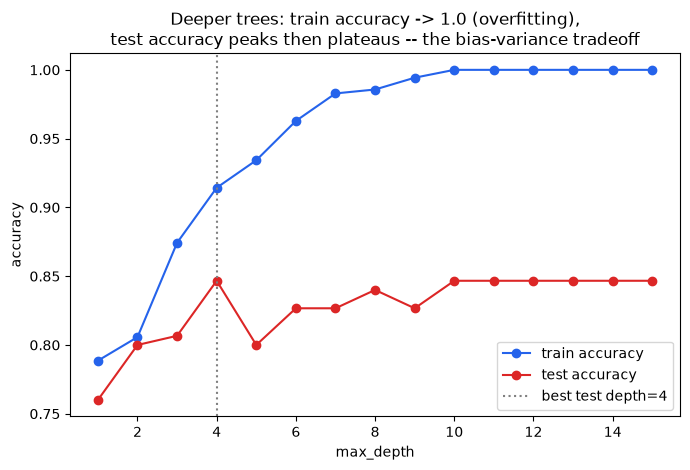

depth 1:  train=0.7886, test=0.7600
depth 15: train=1.0000, test=0.8467


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
from sklearn.model_selection import train_test_split

Xc, yc = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2,
                              flip_y=0.05, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=0)

depths = list(range(1, 16))
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xtr, ytr)
    train_acc.append(t.score(Xtr, ytr)); test_acc.append(t.score(Xte, yte))

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(depths, train_acc, 'o-', label="train accuracy", color="#2563eb")
ax.plot(depths, test_acc, 'o-', label="test accuracy", color="#dc2626")
ax.axvline(depths[np.argmax(test_acc)], color='gray', linestyle=':', label=f"best test depth={depths[np.argmax(test_acc)]}")
ax.set_xlabel("max_depth"); ax.set_ylabel("accuracy")
ax.set_title("Deeper trees: train accuracy -> 1.0 (overfitting),\ntest accuracy peaks then plateaus -- the bias-variance tradeoff")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "depth_bias_variance.png", dpi=140)
plt.show()
print(f"depth 1:  train={train_acc[0]:.4f}, test={test_acc[0]:.4f}")
print(f"depth 15: train={train_acc[-1]:.4f}, test={test_acc[-1]:.4f}")

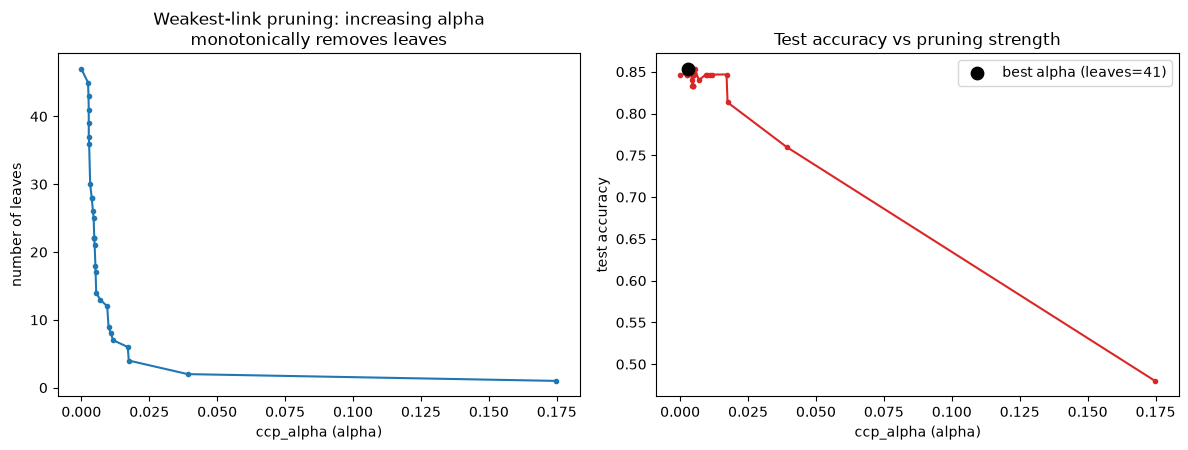

full tree (alpha=0): 47 leaves, test accuracy 0.8467
best-pruned tree: 41 leaves, test accuracy 0.8533


In [8]:
full_tree = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
path = full_tree.cost_complexity_pruning_path(Xtr, ytr)
ccp_alphas = path.ccp_alphas

test_scores, n_leaves = [], []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha).fit(Xtr, ytr)
    test_scores.append(t.score(Xte, yte)); n_leaves.append(t.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(ccp_alphas, n_leaves, marker='o', markersize=3)
axes[0].set_xlabel("ccp_alpha (alpha)"); axes[0].set_ylabel("number of leaves")
axes[0].set_title("Weakest-link pruning: increasing alpha\nmonotonically removes leaves")
axes[1].plot(ccp_alphas, test_scores, marker='o', markersize=3, color="#dc2626")
best_i = np.argmax(test_scores)
axes[1].scatter([ccp_alphas[best_i]], [test_scores[best_i]], color='black', zorder=5, s=80,
                label=f"best alpha (leaves={n_leaves[best_i]})")
axes[1].set_xlabel("ccp_alpha (alpha)"); axes[1].set_ylabel("test accuracy")
axes[1].set_title("Test accuracy vs pruning strength")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "cost_complexity_pruning.png", dpi=140)
plt.show()

print(f"full tree (alpha=0): {n_leaves[0]} leaves, test accuracy {test_scores[0]:.4f}")
print(f"best-pruned tree: {n_leaves[best_i]} leaves, test accuracy {test_scores[best_i]:.4f}")

# Part E - Scale Invariance, Proved Directly

In [9]:
from sklearn.preprocessing import StandardScaler

X2, y2 = make_classification(n_samples=200, n_features=4, random_state=0)
X2_scaled = StandardScaler().fit_transform(X2)
X2_affine = X2 * 1000 + 50

t_raw = DecisionTreeClassifier(max_depth=5, random_state=0).fit(X2, y2)
t_scaled = DecisionTreeClassifier(max_depth=5, random_state=0).fit(X2_scaled, y2)
t_affine = DecisionTreeClassifier(max_depth=5, random_state=0).fit(X2_affine, y2)

print("raw vs standardized -- identical predictions:", np.array_equal(t_raw.predict(X2), t_scaled.predict(X2_scaled)))
print("raw vs standardized -- identical leaf count:  ", t_raw.get_n_leaves() == t_scaled.get_n_leaves())
print("raw vs affine (x1000+50) -- identical predictions:", np.array_equal(t_raw.predict(X2), t_affine.predict(X2_affine)))

raw vs standardized -- identical predictions: True
raw vs standardized -- identical leaf count:   True
raw vs affine (x1000+50) -- identical predictions: True


# Part F - Axis-Aligned Decision Boundaries

On a curved, non-axis-aligned true boundary (the "moons" dataset), a decision tree can only ever approximate it with a staircase of axis-aligned steps.

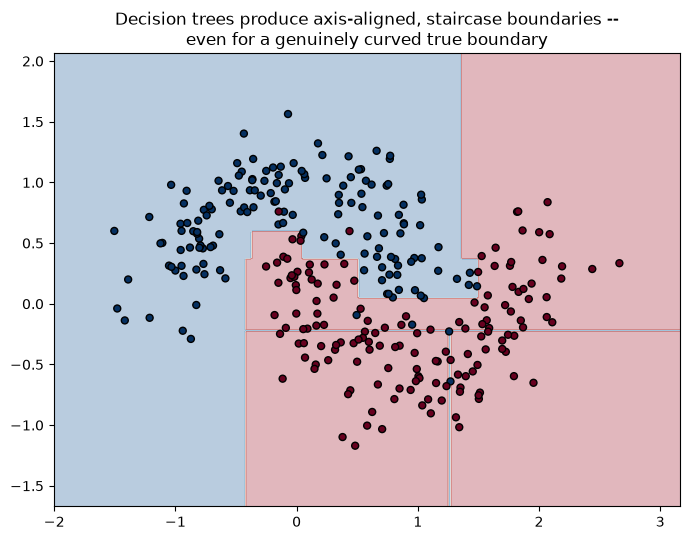

In [10]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=0)
tree_moons = DecisionTreeClassifier(max_depth=6, random_state=0).fit(Xm, ym)

xx, yy = np.meshgrid(np.linspace(Xm[:,0].min()-0.5, Xm[:,0].max()+0.5, 300),
                      np.linspace(Xm[:,1].min()-0.5, Xm[:,1].max()+0.5, 300))
Z = tree_moons.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu_r")
ax.scatter(Xm[:,0], Xm[:,1], c=ym, cmap="RdBu_r", edgecolor='k', s=25)
ax.set_title("Decision trees produce axis-aligned, staircase boundaries --\neven for a genuinely curved true boundary")
fig.tight_layout()
fig.savefig(FIG_DIR / "axis_aligned_boundary.png", dpi=140)
plt.show()

## Self-check before moving on

- [ ] My from-scratch CART implementation matches `sklearn` exactly on both classification (Gini, Entropy) and regression (MSE)
- [ ] I can reproduce the concavity worked example and explain why misclassification error is a worse splitting signal
- [ ] I can construct an XOR-style example showing greedy splitting sees zero gain despite a perfect solution existing
- [ ] I can read a cost-complexity pruning path plot and explain what each axis and curve means
- [ ] I have directly confirmed decision trees are invariant to monotonic feature transformations, not just been told so
- [ ] I can explain why decision boundaries are always axis-aligned, and what real-world boundary shapes this handles poorly

Next: `02-bagging-random-forests.ipynb` — directly motivated by this notebook's variance/instability observations.